In [1]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.datasets import make_regression

In [2]:
X,y = make_regression(n_samples = 500 , n_features = 5 , random_state = 12 , noise = 0)

In [3]:
df = pd.DataFrame(data = X , columns = ["F1", "F2" , "F3" , "F4" , "F5"])
df["target"] = y

In [4]:
df.head()

,F1,F2,F3,F4,F5,target
0,0.775435,-0.597343,-2.454029,-0.317583,0.877347,-77.365872
1,-0.542259,1.368448,-1.580046,0.929778,1.094100,26.124466
2,1.076740,0.667501,0.457691,-2.619493,0.739046,52.074103
3,-0.229107,2.722207,-0.370333,-0.028400,-0.187490,94.225393
4,-0.662289,-1.643468,0.844747,1.931381,-1.996249,-75.499890


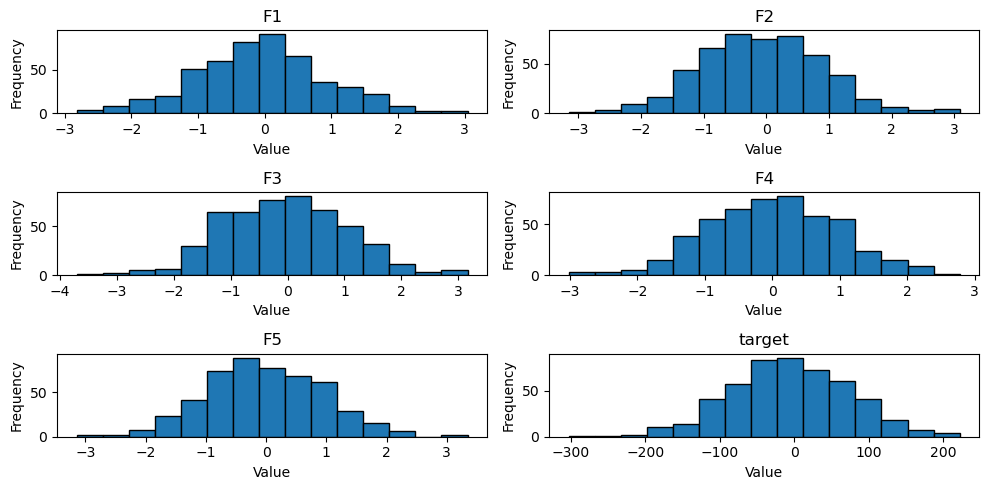

In [5]:
cols = 2
rows = 3

fig, plot = plt.subplots(rows, cols, figsize=(10, 5))
plot = plot.flatten()

for i, feature in enumerate(df.columns[:rows * cols]): 
    plot[i].hist(df[feature].dropna(), bins=15, edgecolor='k')
    plot[i].set_title(feature)
    plot[i].set_xlabel('Value')
    plot[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

def minkowski_distance(x1,x2,p = 2):
    distance = 0
    for i in range(len(x1)):
        distance += abs(x1[i] - x2[i]) ** p

    return distance ** (1/p)
    
class KNNRegressor:
    def __init__(self, k=3, p=2,weighted = False):
        self.k = k
        self.p = p 
        self.weighted = weighted
        
    def fit_knn(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def _compute_distance(self, x):
        distances = [minkowski_distance(x, x_train, p=self.p) for x_train in self.X_train]
        return distances

    def predict_knn(self , X_test):
        predictions = []

        for x in X_test:
            distances = self._compute_distance(x)
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_targets = [self.y_train[i] for i in k_indices]
            if self.weighted == False:
                prediction = np.mean(k_nearest_targets)
            else:
                k_nearest_distances = [distances[i] for i in k_indices]
                weights = [1/(d + 1e-8) for d in k_nearest_distances]
                prediction = sum(w*y for w,y in zip(weights, k_nearest_targets)) / sum(weights)
            predictions.append(prediction)
            
        return predictions
    

In [8]:
# Solution code
from sklearn.metrics import mean_squared_error
k_values = [3, 7, 11]
p_values = [1, 2, 5]

results1 = []
results2 = []
for p in p_values:
    for k in k_values:
        model1 = KNNRegressor(k=k, p=p,weighted = False)
        model1.fit_knn(X_train, y_train)
        y_pred1 = model1.predict_knn(X_test)
        mse1 = mean_squared_error(y_test, y_pred1)
        results1.append([k, p, mse1])

results_df1 = pd.DataFrame(results1,columns=["k", "p", "MSE"])

for p in p_values:
    for k in k_values:
        model2 = KNNRegressor(k=k, p=p,weighted = True)
        model2.fit_knn(X_train, y_train)
        y_pred2 = model2.predict_knn(X_test)
        mse2 = mean_squared_error(y_test, y_pred2)
        results2.append([k, p, mse2])

results_df2 = pd.DataFrame(results2,columns=["k", "p", "MSE"])

print("Using Scratch unweighted KNN model")
best_combination1 = results_df1.loc[results_df1["MSE"].idxmin()]
print(best_combination1)

print("\n \n \nUsing Scratch weighted KNN model")
best_combination2 = results_df2.loc[results_df2["MSE"].idxmin()]
print(best_combination2)


Using Scratch unweighted KNN model
k        7.000000
p        5.000000
MSE    650.926922
Name: 7, dtype: float64

 
 
Using Scratch weighted KNN model
k        7.000000
p        5.000000
MSE    618.774897
Name: 7, dtype: float64


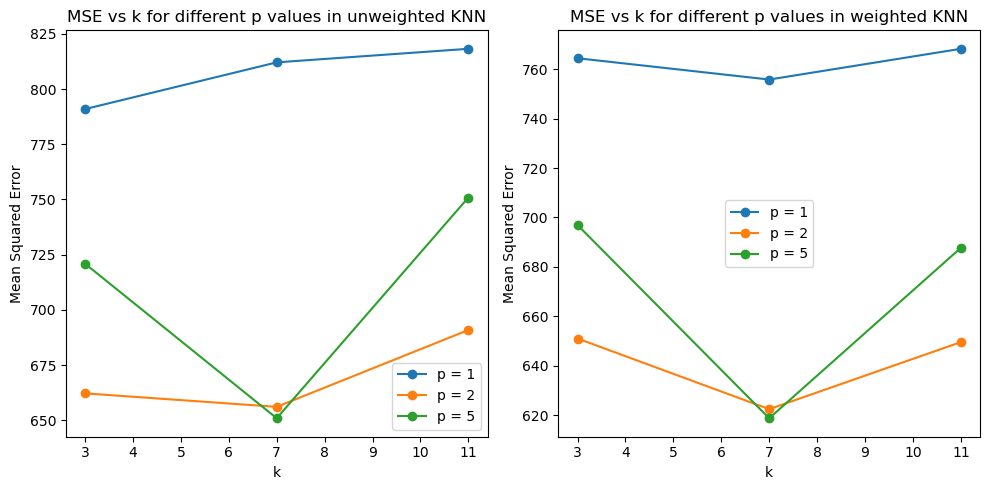

In [9]:
nr = 1
nc = 2

f,a = plt.subplots(nr, nc, figsize=(10, 5))
a = a.flatten()

for p in p_values:
    subset1 = results_df1[results_df1["p"] == p]
    a[0].plot(subset1["k"],subset1["MSE"],marker='o',label= f"p = {p}")

a[0].set_xlabel("k")
a[0].set_ylabel("Mean Squared Error")
a[0].set_title("MSE vs k for different p values in unweighted KNN")
a[0].legend()


for p in p_values:
    subset2 = results_df2[results_df2["p"] == p]
    a[1].plot(subset2["k"],subset2["MSE"],marker='o',label= f"p = {p}")

a[1].set_xlabel("k")
a[1].set_ylabel("Mean Squared Error")
a[1].set_title("MSE vs k for different p values in weighted KNN")
a[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# Solution code
from sklearn.neighbors import KNeighborsRegressor
results3 = []
for i in k_values:
    for j in p_values:
        model3 = KNeighborsRegressor(n_neighbors=i, algorithm='brute',p = j)
        model3.fit(X_train, y_train)
        y_predict3 =model3.predict(X_test)
        MSE3 = mean_squared_error(y_predict3,y_test)
        results3.append([i,j,MSE3])

results4 = []
for i in k_values:
    for j in p_values:
        model4 = KNeighborsRegressor(n_neighbors=i, algorithm='brute',p = j,weights = "distance")
        model4.fit(X_train, y_train)
        y_predict4 =model4.predict(X_test)
        MSE4 = mean_squared_error(y_predict4,y_test)
        results4.append([i,j,MSE4])
        
results_df3 = pd.DataFrame(results3,columns = ["k","p","MSE"])
results_df4 = pd.DataFrame(results4,columns = ["k","p","MSE"])

best_combination3 = results_df3.loc[results_df3["MSE"].idxmin()]
best_combination4 = results_df4.loc[results_df4["MSE"].idxmin()]

print("Using the by default weights as uniform")
print(best_combination3)
print("\n \n \nUsing the weights as distance ")
print(best_combination4)

Using the by default weights as uniform
k        7.000000
p        5.000000
MSE    650.926922
Name: 5, dtype: float64

 
 
Using the weights as distance 
k        7.000000
p        5.000000
MSE    618.774897
Name: 5, dtype: float64


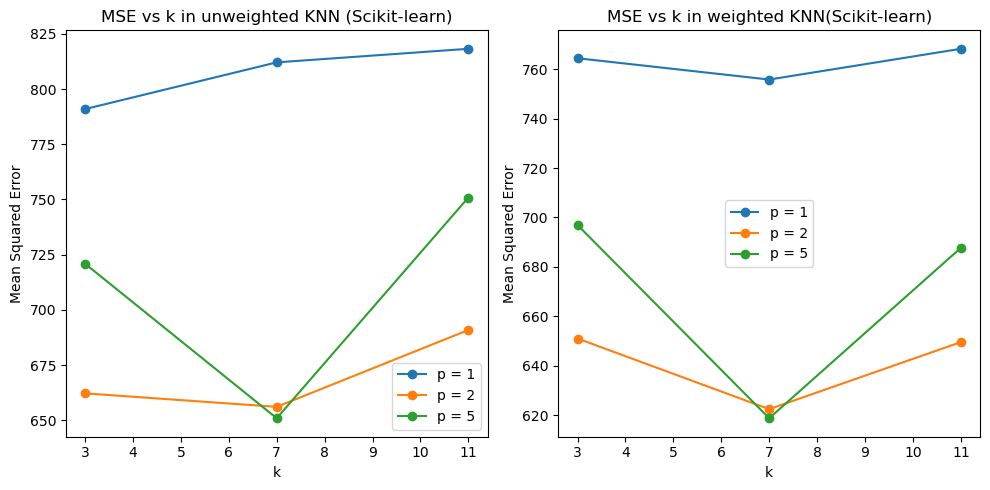

In [11]:
nr = 1
nc = 2

f,a = plt.subplots(nr, nc, figsize=(10, 5))
a = a.flatten()

for p in p_values:
    subset3 = results_df3[results_df3["p"] == p]
    a[0].plot(subset3["k"],subset3["MSE"],marker='o',label= f"p = {p}")

a[0].set_xlabel("k")
a[0].set_ylabel("Mean Squared Error")
a[0].set_title("MSE vs k in unweighted KNN (Scikit-learn)")
a[0].legend()


for p in p_values:
    subset4 = results_df4[results_df4["p"] == p]
    a[1].plot(subset4["k"],subset4["MSE"],marker='o',label= f"p = {p}")

a[1].set_xlabel("k")
a[1].set_ylabel("Mean Squared Error")
a[1].set_title("MSE vs k in weighted KNN(Scikit-learn)")
a[1].legend()

plt.tight_layout()
plt.show()

In [12]:
comparison_table = pd.DataFrame([
    [
        "Scratch KNN",
        "Uniform",
        int(best_combination1["k"]),
        int(best_combination1["p"]),
        best_combination1["MSE"],
        np.sqrt(best_combination1["MSE"])
    ],
    [
        "Scratch KNN",
        "Distance Weighted",
        int(best_combination2["k"]),
        int(best_combination2["p"]),
        best_combination2["MSE"],
        np.sqrt(best_combination2["MSE"])
    ],
    [
        "Scikit-learn KNN",
        "Uniform",
        int(best_combination3["k"]),
        int(best_combination3["p"]),
        best_combination3["MSE"],
        np.sqrt(best_combination3["MSE"])
    ],
    [
        "Scikit-learn KNN",
        "Distance Weighted",
        int(best_combination4["k"]),
        int(best_combination4["p"]),
        best_combination4["MSE"],
        np.sqrt(best_combination4["MSE"])
    ]
],
columns=[
    "Model",
    "Weighting",
    "Best k",
    "Best p",
    "MSE",
    "RMSE"
])


comparison_table


,Model,Weighting,Best k,Best p,MSE,RMSE
0,Scratch KNN,Uniform,7,5,650.926922,25.513270
1,Scratch KNN,Distance Weighted,7,5,618.774897,24.875186
2,Scikit-learn KNN,Uniform,7,5,650.926922,25.513270
3,Scikit-learn KNN,Distance Weighted,7,5,618.774897,24.875186


In [13]:

print("The optimal values of k and p obtained using the scratch implementation are identical to those which we got using Scikit-learn.\nThe MSE and RMSE values also match exactly for both uniform and distance-weighted KNN.\nThe distance-weighted KNN achieved lower prediction error than the uniform-weighted KNN.")

The optimal values of k and p obtained using the scratch implementation are identical to those which we got using Scikit-learn.
The MSE and RMSE values also match exactly for both uniform and distance-weighted KNN.
The distance-weighted KNN achieved lower prediction error than the uniform-weighted KNN.
